In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

from scipy.optimize import minimize
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

In [2]:
Seed = 50
rng = np.random.default_rng(Seed)

# Parameters 

In [3]:
# Parameters for privacy in DP
p_epsilon = 1.0 # the smaller value of epsilon contain stronger privacy
p_delta = 1e-5 # the probability of the failure

In [4]:
# The unit-ball normalization is dist(z_j,z_j')≤ min(r, 2),
# The effective capacity is r < 2
dp_radius = [0.25,0.5,1.0,1.5,2.0]

In [5]:
# To reconstruct the number of target points
targets_datapoints = 40

# Number of trials using gaussian perturbation per radius of it's datapoints
gauss_trial_r = 200

#l2 regularization for lambda parameter of penalty for Binary SVM
Lambda_l2 = 0.01

In [6]:
optimizer_run = 5000 # it runs at 5000 iterations untill it finds optimal value of w and b
conv_tolerance = 1e-3 # it stops optimization when it's improvement is smaller than 10^-3

# Helper function 

In [7]:
# Average predictions of the error
# It computes the average of the squared error into single number for predictions
def mean_square_error (x_actualvalue: np.ndarray, x_predictedvalue: np.ndarray) -> float:
    return float (np.mean((x_actualvalue - x_predictedvalue) ** 2))

# The 1 is added into the right side of matrix.
def bias_addition(X: np.ndarray) -> np.ndarray:
    return np.c_[X, np.ones(X.shape[0])] # It's bias b gets absorbed into w.

# Application of the hinge loss
# It penalizes the datapoints of the model inside gutter for maximum margin classifier.
def hinge_loss(z: np.ndarray) -> np.ndarray:
    return np.maximum(0.0, 1.0 - z) 

# It does the mapping like function f:x->y , where x is training datapoints and y is -1,1 label.
def label_for_datapoints(X: np.ndarray, w: np.ndarray, b: float) -> np.ndarray:
    return np.where(X @ w + b >= 0.0, 1, -1)

# This one shows which datapoint can influence the decision boundary
def canonical_hinge_subgradients(theta: np.ndarray, x: np.ndarray, y: float)-> np.ndarray:
    x_aug = np.r_[x,1.0] # It adds 1 at end of x , but for one single row
    # Application of defintion 2.1 from the proof 
    # where g_i = 0, if y(w^T.x_aug) >= 1, then it's prediction is correct and far away from decision boundary
    #    or g_i =  if y(w^T.x_aug)  otherwise, then it's prediction is wrong side or close to desicion boundary      
    margin_gi = float (y * np.dot(theta, x_aug))
    if margin_gi >= 1.0:
        return np.zeros_like(x_aug)
    return -y * x_aug



# ERM for Binary SVM with hinge loss

From the application of regularised erm for binary svm with hinge loss as given in the proof:
$$ F_{D}(w)= \frac{1}{n}\sum_{i=1}^{n}l_{SVM}(w;z_i)+\frac{\lambda}{2}||w||^2_2$$,
 where $$w = \theta$$ and $$\lambda >0$$

In [8]:
class HingeBinarySVM:
    
    # The datapoints of the model who didn't learn anything
    def __init__ (self,lambda_: float = 0.01): #Knob of parameter w.r.t l2 regularization
        self.lambda_ = lambda_ 
        self.w = None # No weights learned
        self.b = None # No bias learned
        
        
    # This is the function to determine the optimizer score. If the score is lower, the model is better    
    def _objective(self, theta: np.ndarray, XY: np.ndarray) -> float:
        # each training datapoints is multiplied by label and dot products multiplied with weights
        svm_margins = XY @ theta  
        # It runs through every margin of the hinge loss,
        #and it gives the average value of the loss.    
        erm = float(np.mean(hinge_loss(svm_margins))) 
        # Implementing the l2 regularizer, where it includes the penalization of weights
        # The more it's penalty the simpler the model
        l2_regularizer = 0.5 * self.lambda_ * np.dot(theta, theta) 
        return erm + l2_regularizer
    
    def fit(self, X: np.ndarray, y: np.ndarray):
        # Adding the value of X into bias and multiplies with labels
        X_bias = bias_addition (X)
        XY = X_bias * y[:, None]
        # Starting with weight value 0
        theta_value_0 = np.zeros(X_bias.shape[1], dtype = np.float64)
        # untill the loss function stops improvement,it will keep on adjusting the weight
        result = minimize(
            fun = self._objective, # it mentions about the height 
            x0 = theta_value_0,
            args = (XY,),
            method = "L-BFGS-B",# the algorithm to find the lowest value 
            tol = conv_tolerance,
            options = {"maxiter":optimizer_run},          
        )
        
        if not result.success:
            raise RuntimeError(result.message) # If optimizer can't find the value then it sends error message
        self.w = result.x[:-1]#last weight with value
        self.b = result.x[-1]# last bias with value
        return self
    
    @property
    def theta(self) -> np.ndarray:
        return np.r_[self.w, self.b]
    
    # It returns the score of the training data with label
    def predict(self, X: np.ndarray) -> np.ndarray:
        return label_for_datapoints(X, self.w, self.b)
  
    # It returns the accuracy score of the correct value
    def score (self, X: np.ndarray, y: np.ndarray) -> float:
        return accuracy_score(y, self.predict(X))

    

## Loading for the MNIST 3,8 data

In [9]:
import torch
from torchvision import datasets, transforms

#Implementation of MNIST dataset using pytorch for {3,8}.

Normalize_transform = transforms.ToTensor() # MNIST image to normalized pytorch

# Loading of the Dataset for MNIST
MNIST_Dataset = datasets.MNIST(root='./data', train=True, download=True, transform=Normalize_transform)

selection = torch.logical_or(MNIST_Dataset.targets == 3, MNIST_Dataset.targets == 8) # filtering the dataset for {3,8}

# It keeps the image and label for data and targets
MNIST_Dataset.data = MNIST_Dataset.data[selection]
MNIST_Dataset.targets = MNIST_Dataset.targets[selection]

MNIST_Dataset.targets = torch.where(MNIST_Dataset.targets == 8, 1, -1) #Formation of Binary format

#Flattening of the images for x and y from the MNIST value of Data and targets
X_image = MNIST_Dataset.data.view(-1, 28*28).float() / 255.0
Y_image = MNIST_Dataset.targets.view(-1).float()

## It applies from the proof of Unit ball normalization and also it's for loading of MNIST data 
$$\phi'(x_i) = \frac{\phi(x_i)}{\phi_0}, \quad \phi_0 = \max_{x_i \in X}\|\phi(x_i)\|_2$$


In [10]:
# It stratify 500 random sample from digit 3(-1) and 8(+1),which combines to form
# 1000 datapoints, and it's done to save the computational cost and to provide proper balance 
# of the SVM and Fixed seed is 42.

def binary_dataset_loading_mnist_3_8():
    
    X_all = X_image.numpy().astype(np.float64)
    y_all = Y_image.numpy().astype(np.float64)
    
    rng_data = np.random.default_rng(42)  # fixed seed 
    idx_pos  = np.where(y_all == 1)[0]   # for digit 8(+)
    idx_neg  = np.where(y_all == -1)[0]  # for digit 3(-)
    
    # Total of 500+500 class = 1000 datapoints to be classified.
    chosen_pos = rng_data.choice(idx_pos, size=500, replace=False)
    chosen_neg = rng_data.choice(idx_neg, size=500, replace=False)
    chosen     = np.concatenate([chosen_pos, chosen_neg])
    rng_data.shuffle(chosen)

    return X_all[chosen], y_all[chosen]
  

def load_selected_dataset(dataset_name="MNIST_3_8"):
    if dataset_name == "MNIST_3_8":
        return binary_dataset_loading_mnist_3_8()
    else:
        raise ValueError("dataset_name must be 'MNIST_3_8' ")


# It squeeze into unit ball normalization <=1 for all the dataset 
def unit_ball_normalization(X: np.ndarray):
# For each 784 feature column it finds out it's mean and it divide from it's standard deviation value 
# and tries to scale it towards norm <=1
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
# It computes the l2 morm for every 1000 patient row and then it finds out the maximum norm value for phi_0
    max_norm = float (np.linalg.norm(X_scaled, axis=1).max())
    if max_norm == 0.0:
        raise ValueError("The unit ball normalization is undefined because the global max norm is 0")
    X_unit = X_scaled / max_norm # it re-scales it strictly towards ||phi(x_i)||_2 <= 1
    return X_unit, scaler, max_norm


## Implementation of the Gaussian noise

It comes from equation, after applying the triangle inequality
$$\sigma \geq \frac{\min\{r,2\}}{\varepsilon \lambda n}\sqrt{2\ln(1.25/\delta)}$$

So as we can see that it's sensitivity can't reach beyond 2

In [11]:
# Implementing delta_2,effective_r <= r/lambda.n

# r is the adjancency value of radius ball
# lambda_ is the regularization parameter
# n is the dataset used for training the binary svm
# effective r is the min(r,2)
def delta_l2_sensitivity(r:float, lambda_: float, n: int):
    effective_r = min(float(r), 2.0)
    delta_2 = effective_r / (lambda_ * n)
    return float (delta_2), float(effective_r) 

def output_perturbation_gaussian_noise(
    theta: np.ndarray,
    r: float,
    epsilon: float,
    delta: float,
    lambda_: float,
    n: int,
    seed: int
    
):
   
    
    # from the proof implementing the formula for sigma of gaussian mechanism
    
    # that is sigma >= delta_2(r) * sqrt(2 log (1.25/delta) / epsilon 
     
    delta_2, effective_r = delta_l2_sensitivity(r, lambda_, n)
    sigma = (
        np.sqrt(2.0 * np.log (1.25 / delta))
        * delta_2 
        / epsilon
    )
    
    noise_rng = np.random.default_rng(seed) # gaussian random generator
    theta_dp = theta + noise_rng.normal(0.0, sigma, size=theta.shape)
    return theta_dp, float(sigma), float(effective_r)
    

# Distribution of $residual_{d+1}$

It process it as follows:

1) 40 targets $\times$ label +1 and -1.

2) Computing residual $\hat{\theta}$.

3) Difference for with noise res $\equiv -y_{target}$+noise .

4) Difference without noise res $\equiv -y_{target}$.

=== Non-DP residual[-1] ===
y=+1: mean=-0.9999,  std=0.0000
y=-1: mean=1.0001,  std=0.0000
Threshold (midpoint): 0.0001

=== DP r=0.25 residual[-1] ===
y=+1: mean=-1.8295,  std=7.4411
y=-1: mean=0.1658,  std=7.4507


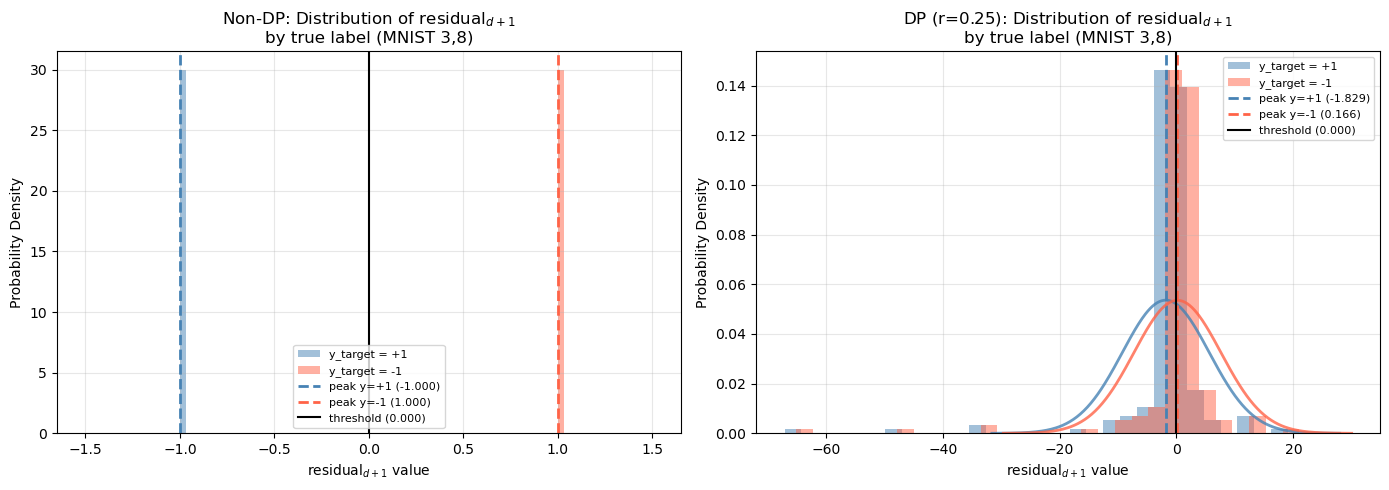

Distribution plot saved.


In [12]:
# In this it loops on all n datapoints except the target because the function skip 
# that row when computing the sum of subgradients, so the residual reveals information about patient record.
def compute_residual_last(X, y, target_index, theta, lambda_):
    n = X.shape[0]
    s = np.zeros_like(theta)# s= sum of subgradients g_i({\theta})
    for i in range(n): 
        if i == target_index:
            continue 
        s += canonical_hinge_subgradients(theta, X[i], y[i]) # Computation of residual -n*lambda*theta - s
    return float((-n * lambda_ * theta - s)[-1]) # returns only the last component [-1] that is $-y_target$

# Loading of the data and training non-DP SVM model
X_data_dist, y_label_dist = load_selected_dataset("MNIST_3_8") # loading the data
X_dist, _, _ = unit_ball_normalization(X_data_dist) # normalizing to unit ball
n_dist = X_dist.shape[0] 
model_dist = HingeBinarySVM(lambda_=Lambda_l2).fit(X_dist, y_label_dist)# trains clean non-DP SVM
theta_dist = model_dist.theta # which gets $\hat{\theta}$

target_indices_dist = np.random.default_rng(99).choice(n_dist, size=40, replace=False) # Randomly picks 40 target datapoints

# Non-DP clean distribution
"""for each 40 target datapoints:
compute residual[-1] using $\hat{\theta}$
If true label = +1 -> store it in res_clean_pos with expected result ≡ -1 and 
If true label = -1 -> store it in res_clean_neg with expected result ≡ +1 
"""
res_clean_pos, res_clean_neg = [], []
for ti in target_indices_dist:
    val = compute_residual_last(X_dist, y_label_dist, int(ti), theta_dist, Lambda_l2)
    (res_clean_pos if y_label_dist[int(ti)] == +1 else res_clean_neg).append(val)

print("=== Non-DP residual[-1] ===")
print(f"y=+1: mean={np.mean(res_clean_pos):.4f},  std={np.std(res_clean_pos):.4f}")
print(f"y=-1: mean={np.mean(res_clean_neg):.4f},  std={np.std(res_clean_neg):.4f}")
threshold = (np.mean(res_clean_pos) + np.mean(res_clean_neg)) / 2
print(f"Threshold (midpoint): {threshold:.4f}")

# DP distribution  for r=0.25
""" for each 40 target datapoints:
          for each 200 gaussian trials:
           Add gaussian noise to \hat_{theta}-> \hat_{theta}_DP
           Compute residua[-1] using \hat_{theta}_DP
           Separating true label like applied for Non-DP
    Total values collected:
    40 targets x 200 gaussian trials = 8000 values which it becomes -400 and +400 in x-axis
    for y=+1 and y=-1 group separately
"""
res_dp_pos, res_dp_neg = [], []
for ti in target_indices_dist:
    for trial in range(200):
        th_noisy, _, _ = output_perturbation_gaussian_noise(
            theta_dist, 0.25, p_epsilon, p_delta, Lambda_l2, n_dist, 10_000 + trial)
        val = compute_residual_last(X_dist, y_label_dist, int(ti), th_noisy, Lambda_l2)
        (res_dp_pos if y_label_dist[int(ti)] == +1 else res_dp_neg).append(val)

print(f"\n=== DP r=0.25 residual[-1] ===")
print(f"y=+1: mean={np.mean(res_dp_pos):.4f},  std={np.std(res_dp_pos):.4f}")
print(f"y=-1: mean={np.mean(res_dp_neg):.4f},  std={np.std(res_dp_neg):.4f}")

"""
It shows the distribution of residual[-1] values where blue=+1 targets,for red=-1 targets
and in y-axis it shows the probability density which it represent how 
likely that each value of residual_{d+1} to occur
"""
""" Computing the theoritical gaussian curve N(mu,sigma^2), where mu is the mean collected from 
residual[-1] and sigma^2 is the standard deviation value collected from residual[-1] values. It plots the smooth
Gaussian Curve on top of histogram which it shows theoritical distribution matches data"""
"""
It's Midpoint between two peaks ,which it's used to decide is it residual[-1] from y=+1 or from y=-1.
If residual [-1]< threshold -> y_target =+1
If residual [-1 ]> threshold -> y_target =-1
"""       
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pos_data, neg_data, title in [
    (axes[0], res_clean_pos, res_clean_neg,
     'Non-DP: Distribution of residual$_{d+1}$\nby true label (MNIST 3,8)'),
    (axes[1], res_dp_pos,   res_dp_neg,
     'DP (r=0.25): Distribution of residual$_{d+1}$\nby true label (MNIST 3,8)')
]:
    ax.hist(pos_data, bins=30, alpha=0.5, color='steelblue',
            density=True, label='y_target = +1')
    ax.hist(neg_data, bins=30, alpha=0.5, color='tomato',
            density=True, label='y_target = -1')
    for data, color, label_prefix in [
        (pos_data, 'steelblue', 'y=+1'),
        (neg_data, 'tomato',    'y=-1')
    ]:  
        mu, sd = np.mean(data), np.std(data)
        ax.axvline(mu, linestyle='--', linewidth=2, color=color,
                   label=f'peak {label_prefix} ({mu:.3f})')
        if sd > 1e-6:
            xr = np.linspace(mu - 4*sd, mu + 4*sd, 300)
            ax.plot(xr, stats.norm.pdf(xr, mu, sd),
                    linewidth=2, color=color, alpha=0.8)  
    ax.axvline(threshold, linestyle='-', linewidth=1.5,
               color='black', label=f'threshold ({threshold:.3f})')
    ax.set_xlabel('residual$_{d+1}$ value')
    ax.set_ylabel('Probability Density')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("mnist_residual_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Distribution plot saved.")

## Reconstruction Attack
It has record of 1000 datapoints for patient and all 1000 datapoints it's trained with SVM and it releases the trained model to the public $\hat{\theta}$. 
The adversary somehow gets access towards 999 datapoints from breaching and it want to breach one of it's target datapoints of it's target record considered as $x_{target}$,which it could influence it's decision boundary.
So it performs the mathematics as follows:

$$  \sum_{i=1}^{n} g_i(\hat{\theta})+ n\lambda\hat{\theta} = 0$$
Where $\sum_{i=1}^{n} g_i(\hat{\theta})$ is the sum of all subgradients for patient and $n\lambda\hat{\theta}$ is the regularization term.

It performs the first optimality condition,where the SVM finishes it's training and the gradient it becomes exactly 0.

The adversary tries to recover it's target datapoint $x_{target}$ to obtain the reconstruction attack as
$$  \sum_{i\neq x_{target}} g_i(\hat{\theta})+ n\lambda\hat{\theta}+ g_{target}(\hat{\theta}) = 0$$,
where $\sum_{i\neq x_{target}} g_i(\hat{\theta})+ n\lambda\hat{\theta}$ the adversary knows this, but the adversary doesn't know $g_{target}(\hat{\theta})$, so this  becomes residual and it is denoted as
$$  g_{target}(\hat{\theta}) = -\sum_{i\neq x_{target}} g_i(\hat{\theta})- n\lambda\hat{\theta}$$

If the target is in the active region (margin<1),then it's subgradient is dependent on $x_{target}$ and $y_{target}$, from which the $\theta$ it drops out if it's active region is found. Therefore,
$g_{target} = -y_{target}[x_{target};1]$, it is interpreted as
from the definition  of the theoretical analysis proof
$$g_{target} = -y_{target}\cdot 
\begin{bmatrix} 
x_{target}[1] \\ 
\vdots \\ 
x_{target}[d] \\ 
1 
\end{bmatrix}$$

So the recoverable $$\hat{x}_{raw\,target} = \frac{-y_{target} \times x_{target}}{-y_{target} \times 1} = x_{target}$$,
it could also be considered as 
$$\hat{x}_{raw\,target} = \frac{residual_{1:d}}{residual_{d+1}}$$
,which recovers the $x_{target}$ also as it's observed that in the last residual it contains only $-y_{target}$its label is also recovered

for this $\hat{x}_{raw\,target} = \frac{residual_{1:d}}{residual_{d+1}}$, while dividing it gives the value of last residual not exactly $\{-1,+1\}$ that result in clipping formula doesn't apply at all because the MSE decreses with r increases. 

To solve this problem, it's application as follows
From Non-DP distribution analysis:
- $y_{target} = +1 \Rightarrow \text{residual}_{d+1} \approx -1$ (negative side), std = 0.000
- $y_{target} = -1 \Rightarrow \text{residual}_{d+1} \approx +1$ (positive side), std = 0.000
- Threshold = 0.0

$$\text{assumed\_last} = \begin{cases} -1 & \text{if } \text{residual}_{d+1} < 0 \\ +1 & \text{if } \text{residual}_{d+1} > 0 \end{cases}$$

$$\hat{x}_{raw\,target} = \frac{\text{residual}_{1:d}}{\text{assumed\_last}}$$




In [13]:
"""The Distribution based on analysis:
y=+1 -> residual[-1] peaks at -1.00 in negative side
y=-1 -> residual[-1] peaks at +1.00 in positive side
so it's midpoint=0.0
"""
MNIST_THRESHOLD = 0.0



def reconstruct_from_subgradient_residual(
    X: np.ndarray, # It's full dataset with 784 features (1000 x 784)
    y: np.ndarray, # All of the labels {-1,+1}
    target_index: int, #it determines which image to attack
    theta_released: np.ndarray, #The final released weight
    lambda_: float, # regularization parameter
    residual_tol: float = 1e-10, # Safety threshold
):
    # In this loop it sums up all the 999 known datapoints. The adversary does know that target exist but not it's 
    # feature
    sum_known_subgradients = np.zeros_like(theta_released) #start at zero
    n = X.shape[0]
    for i in range(n):
        if i == target_index: # It loops over all 999 datapoints
            continue
        # In here the adversary has the released weight theta and x[i] and y[i] due to breaching of data but the 
        # adversary doesn't have the exact target datapoint for patient x[target] and y[target], that is why the 
        # adversary skip the target datapoints
        sum_known_subgradients += canonical_hinge_subgradients(theta_released,X[i],y[i])  
    # This performs the exact mathematics of g_{target}= -y{target}*[x{target};1]
    residual = -n * lambda_ * theta_released - sum_known_subgradients
    last_residual = float(residual[-1]) # it's y_{target}
        
    # If the residual is near 0, it means it's in inactive region and the subgradient≈0
    # thus the adversary cannot reconstruct
    if abs(last_residual)<= residual_tol:
        return np.zeros(X.shape[1], dtype=np.float64), 0, False, residual #False=Success
    
    
    """ Distribution based  for y_target
     if residual[-1] < 0 -> y_target = +1 -> assumed_last = -1 as denominator
     if residual[-1] > 0 -> y_target = -1 -> assumed_last = +1 as denominator"""
    if last_residual < MNIST_THRESHOLD:
        estimated_y  = +1
        assumed_last = -1.0
    else:
        estimated_y  = -1
        assumed_last = +1.0

    y_hat     = estimated_y
    
     # In here x_hat_raw =(-y{target}. x{target})/(y{target})=x{target},which shows the recovery from formula given as
        # \clip_x{raw target}.
        #y_hat = y{target}, then it's label is also recovered
        #In non-DP it shows it's nearly equal to zero but as DP noise is added then it shows it's difference
    x_hat_raw = residual[:-1] / assumed_last 
     
    x_hat_norm = float(np.linalg.norm(x_hat_raw))  
        
     
    if x_hat_norm < 1e-10: # In here the x_hat_raw is 0, therefore attack fails
        return np.zeros(X.shape[1], dtype=np.float64), y_hat, False, residual #False= Success
        
    return x_hat_raw.astype(np.float64), y_hat, True, residual # True=Success

## Likelihood-Style Target Identification Attack

This part of the code implements a likelihood-style informed-adversary target identification attack. The purpose is to use the SVM optimality condition to measure which candidate target is most consistent with the released model parameter.

Let the released model parameter be denoted by
$$\theta_{\mathrm{rel}}.$$
This can be either the non-private parameter
$$\theta_{\mathrm{rel}} = \hat{\theta},$$
or the differentially private released parameter
$$\theta_{\mathrm{rel}} = \hat{\theta}_{DP} = \hat{\theta} + \vartheta, \qquad \vartheta \sim \mathcal{N}(0,\sigma^2 I).$$

Therefore, the DP noise is not generated inside the likelihood attack function itself. Instead, the function receives the already released parameter as input. If $\theta_{\mathrm{rel}}=\hat{\theta}_{DP}$, then the effect of Gaussian DP noise is already included in the computation.

For a binary SVM, the canonical hinge-loss subgradient for a data point $z_i=(x_i,y_i)$ is
$$g_i(\theta_{\mathrm{rel}}) = \begin{cases} 0, & \text{if } y_i\langle \theta_{\mathrm{rel}}, [x_i;1]\rangle \geq 1,\\[4pt] -y_i[x_i;1], & \text{if } y_i\langle \theta_{\mathrm{rel}}, [x_i;1]\rangle < 1. \end{cases}$$
Here $[x_i;1]$ denotes the feature vector with an added bias coordinate.

At the optimum of the non-private SVM objective, the first-order optimality condition is approximately
$$\sum_{i=1}^{n} g_i(\theta) + n\lambda\theta \approx 0.$$
The reconstruction attack uses this condition as a consistency check. If a candidate target is the correct missing point, then adding its subgradient contribution to the known dataset should make the optimality residual small.

For each true target $z_t$, the informed adversary knows
$$D_-^{(t)} = D \setminus \{z_t\}.$$
The adversary then searches over a fixed candidate set
$$\mathcal{T} = \{z_1,\ldots,z_{40}\}.$$
For each candidate $z_c \in \mathcal{T}$, the code computes the residual score
$$\mathrm{score}(t,c) = \left\| \sum_{i\in D_-^{(t)}} g_i(\theta_{\mathrm{rel}}) + g_c(\theta_{\mathrm{rel}}) + n\lambda\theta_{\mathrm{rel}} \right\|_2.$$

Since
$$\sum_{i\in D_-^{(t)}} g_i(\theta_{\mathrm{rel}}) = \sum_{i=1}^{n} g_i(\theta_{\mathrm{rel}}) - g_t(\theta_{\mathrm{rel}}),$$
the score can be computed efficiently as
$$\mathrm{score}(t,c) = \left\| \sum_{i=1}^{n} g_i(\theta_{\mathrm{rel}}) - g_t(\theta_{\mathrm{rel}}) + g_c(\theta_{\mathrm{rel}}) + n\lambda\theta_{\mathrm{rel}} \right\|_2.$$

The code first computes the subgradient matrix
$$G = \begin{bmatrix} g_1(\theta_{\mathrm{rel}})\\ g_2(\theta_{\mathrm{rel}})\\ \vdots\\ g_n(\theta_{\mathrm{rel}}) \end{bmatrix}.$$
Then it computes
$$\mathrm{base} = \sum_{i=1}^{n} g_i(\theta_{\mathrm{rel}}) + n\lambda\theta_{\mathrm{rel}}.$$


For each target $t$ and candidate $c$, the residual is then
$$\mathrm{base} - g_t(\theta_{\mathrm{rel}}) + g_c(\theta_{\mathrm{rel}}).$$

which equals:
$$  \sum_{i\in D_{-}^{(t)}} g_i(\theta_{\mathrm{rel}})  + g_c(\theta_{\mathrm{rel}}) + n\lambda\theta_{\mathrm{rel}} $$


The candidate with the smallest residual norm is selected:
$$\hat{z}_t = \arg\min_{z_c\in\mathcal{T}} \mathrm{score}(t,c).$$

This is called likelihood-style target identification because, under Gaussian output perturbation, a candidate that gives a smaller residual is interpreted as being more consistent with the observed released parameter. Therefore, smaller residual corresponds to a higher likelihood-style score.

The target identification accuracy is then computed as
$$\mathrm{TargetAcc} = \frac{1}{|\mathcal{T}|} \sum_{z_t\in\mathcal{T}} \mathbf{1}[\hat{z}_t = z_t].$$

Since the candidate set contains $40$ target points, random guessing corresponds to
$$\frac{1}{40}=0.025.$$


In [14]:
"""
    Vectorized canonical hinge subgradients for all datapoints.

    Each row is

        g_i(theta) = 0                 if y_i (theta, [x_i; 1]) >= 1
                   = -y_i [x_i; 1]    otherwise

    Assumes bias_addition(X) returns [X, 1] with shape (n, d+1).
"""

def canonical_hinge_subgradient_matrix(
    theta: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
) -> np.ndarray:
    
    X_aug = bias_addition(X) # Converts x_i to [x_i;1] \in R^{d+1}
    margins = y * (X_aug @ theta) # Computing y_i(0,[x_i;1])
    active = margins < 1.0 # This finds datapoints that are inside margin or missclassified

    G = np.zeros_like(X_aug, dtype=np.float64) # Creates matrix G
    G[active] = -y[active, None] * X_aug[active] # output shape (n,d+1)

    return G


def likelihood_candidate_attack_all_targets(
    X: np.ndarray, # full normalized dataset features
    y: np.ndarray, # labels
    target_indices: np.ndarray, # true traget points selected from the dataset
    candidate_indices: np.ndarray, # possible candidite targets
    theta_released: np.ndarray,# released model parameter, either Non-DP or DP
    lambda_: float, # SVM regularization parameter
):
    
    n = X.shape[0] # Dataset of size n

    target_indices = np.asarray(target_indices, dtype=int) 
    candidate_indices = np.asarray(candidate_indices, dtype=int)

    # computing it's subgraident G_i = g_i(\theta)
    G = canonical_hinge_subgradient_matrix(theta_released, X, y)

    sum_all = G.sum(axis=0) # computing the sum of g_i(\theta)
    base = sum_all + n * lambda_ * theta_released # computing full optimal residual

    target_G = G[target_indices] # extracting g_t(\theta)
    candidate_G = G[candidate_indices] #extracting g_c(\theta)

    """
    the score is computed as

        residual_tensor = || sum_i g_i(theta) - g_t(theta) + g_c(theta) + n lambda theta ||_2.       
    """
    
    
    residual_tensor = (
        base[None, None, :]
        - target_G[:, None, :]
        + candidate_G[None, :, :]
    )

    """score_matrix:
            Matrix of shape (#targets, #candidates), where entry (a,b)
            is the residual score for target_indices[a] and candidate_indices[b]."""
    
    score_matrix = np.linalg.norm(residual_tensor, axis=2)

    best_positions = np.argmin(score_matrix, axis=1)
    predicted_indices = candidate_indices[best_positions]#predicted_indices:Predicted candidate index for each target.
    
    """success_rate:
            Fraction of targets where selected candidate equals true target."""
    success_rate = float(np.mean(predicted_indices == target_indices)) 
    mean_best_score = float( 
        np.mean(score_matrix[np.arange(len(target_indices)), best_positions])
    )#mean_best_score:Mean minimum residual score across targets.

    return success_rate, mean_best_score, predicted_indices, score_matrix

# Main Experiment Pipeline

## Note: Implementation of Clipping

The $\hat{x}_{clip}$ it's recovered estimate by adversary, which it's clipped into it's unit ball, which it's denoted as

$$\hat{x}_{clip} = \hat{x}_{raw\,target} \times \min\left\{1,\ \frac{1}{\|\hat{x}_{raw\,target}\|}\right\}$$



Then the MSE is computed as 
$$ \text{MSE}=||\hat{x}_{clip}-x_{target}||^2$$

### Implementing fixed target set and likelihood-style candidate selection

This notebook keeps the original subgradient-residual reconstruction MSE, and adds an additional informed-adversary metric.
For each fixed target $z_t$, the adversary knows $D_- = D \setminus \{z_t\}$ and searches over the fixed candidate set $\mathcal{T}$ chosen with seed 99. The selected candidate is the one with the smallest SVM optimality residual. Under Gaussian output perturbation, this is used as a practical likelihood-style proxy for choosing the target candidate most consistent with the released noisy model.


In [15]:
# Loading and preprocessing of the data

def run_main_experiment(dataset_name="MNIST_3_8"):
    
    # Loading of the data for 1000 datapoints of the patient and 784 feature measurement
    X_data, y_label = load_selected_dataset(dataset_name)
    
    # The data performs the unit-ball normalization, which 1000 datapoints of patient * 784 feature measurement
    # it's normalized <= 1.0 as per Assume 1 of the proof   
    X, scaler, max_norm = unit_ball_normalization(X_data)
    n, d = X.shape
    
    
    # It is sample of 40 target indices from dataset, where the 40 unique target datapoints is chosen and it's
    # same 40 images are attacked on every single run, which determines the reproducible result 
    """
    It fix it's seed 99, pick 40 incides 
    so the same 40 images are attacked on every 
    single run and same image is never picked
    twice as target."""
    target_count = min(targets_datapoints, n) # setted as min(40,1000)
    target_indices = np.random.default_rng(99).choice(n, size=target_count, replace=False)
    
    # Fixed candidate set for likelihood-style informed adversary.
    # We use the same 40 points as both evaluation targets and candidates.
    candidate_indices = target_indices.copy()

    
    # Applying the non-DP SVM
    """It follows with training SVM with regularization 0.01 and it trains all images and applies the equation 1
    from the proof."""
    model_nonDP = HingeBinarySVM(lambda_=Lambda_l2).fit(X, y_label)
    theta_nonDP = model_nonDP.theta # It's released model without DP, where it has 785 learned feature model numbers.
    baseline_acc = model_nonDP.score(X, y_label) # Classification of accuracies.
    
    """ In here it performs the reconstruction attack on non-DP baseline.
    In this case the reconstruction attack it runs for released model parameter for theta_hat for each 40 targets and
    the adversary works on it's step by step as follows:
    1) The adversary knows the theta_nonDP except for x_target and y_target
    2) It computes sum of all 999 datapoints of subgradient
    3) It works on the formulation of g_{target}_theta_hat
    4) adversary works on recovery of x_hat_raw = residual[:-1] / assumed_last (+1,-1)
    5) Instead of dividing the last_residual, the assumption of  assumed_last is used
    """
    
    # storage for error and success of baseline
    baseline_mses = []
    baseline_success = []
    baseline_norms = [] # it stores the average of ||x_hat_raw|| for each target
       
    # The attacker uses the non-theta DP to recover the true target value for \clip_x{raw target}
    for ti in target_indices: 
        x_hat_raw, _, success, _ = reconstruct_from_subgradient_residual(
            X=X, y=y_label, target_index=int(ti),
            theta_released=theta_nonDP, lambda_ = Lambda_l2,
        )
        if success:
            # using the formula of x_hat_clip as given in the markdown
            norm_hat   = float(np.linalg.norm(x_hat_raw))
            scale      = min(1.0, 1.0 / norm_hat) if norm_hat > 1e-10 else 0.0
            x_hat_clip = x_hat_raw * scale
            baseline_mses.append(mean_square_error(X[int(ti)], x_hat_clip))
            baseline_norms.append(norm_hat) # before clipping value for ||x_hat_raw||
        else:
            baseline_mses.append(0.0) # Attack is skipped because of target in inactive region
            baseline_norms.append(0.0)
        baseline_success.append(float(success))
        
        # Likelihood-style target selection for Non-DP baseline.
    baseline_like_acc, baseline_like_score, baseline_predicted_indices, baseline_score_matrix = (
        likelihood_candidate_attack_all_targets(
            X=X,
            y=y_label,
            target_indices=target_indices,
            candidate_indices=candidate_indices,
            theta_released=theta_nonDP,
            lambda_=Lambda_l2,
          )
        )
        
    baseline_row = {
            "r"                   : 0.0, # no radius
            "effective_r"         : 0.0, # no effective radius
            "sigma_mean"          : 0.0, # no noise
            "MSE_mean"            : float(np.mean(baseline_mses)), # average direction MSE for 40 target
            "MSE_std"             : float(np.std(baseline_mses)),  # standard deviation value for 40 target
            "Acc_mean"            : float(baseline_acc), # Accuracy value for non-DP
            "Acc_std"             : 0.0, # no trails, therefore no variation
            "Recoverable_fraction":float(np.mean(baseline_success)), # the adversary performed for 40 target successfully
            "Mean_xhat_norm"      : float(np.mean(baseline_norms)),
            "Likelihood_Target_Acc": float(baseline_like_acc),
            "Likelihood_Score_mean": float(baseline_like_score),
            "Likelihood_Score_std": 0.0,
                       
        }    
     
    # Implementing the weak DP adjancency of radius r    
    results = []
    for r in dp_radius: 
        # It is empty list,which stores the value after 200 trails
        trial_mse_means = [] 
        trial_acc_means   = []
        trial_recoverable = []
        trial_likelihood_success = []
        trial_likelihood_scores = []
        sigma_values      = []
        eff_r_values      = []
        trial_norm_means = [] # it stores the average value of mean ||x_hat_raw|| per trial for DP
        
        for trial in range(gauss_trial_r):# for each r it draws 200 perturbation trails
            """ For each 200 trial it draws it's fresh independent noise vector, by applying from it's proof corollary
            4.2 , where from trial 1 to 199 it injects it's noise and it implements from seed 10000 to 10199, where it 
            comes around theta_hat_DP = theta_hat + noise_199"""
            
            theta_dp, sigma, eff_r = output_perturbation_gaussian_noise(
                theta = theta_nonDP,
                r     = r,
                epsilon = p_epsilon,
                delta = p_delta,
                lambda_ = Lambda_l2,
                n = n,
                seed=10_000 + trial,                
            )
            sigma_values.append(sigma)
            eff_r_values.append(eff_r)
            
            # Checking the accuracy of it's noise model
            """ In here the theta_dp it's weight and bias are injected with gaussian noise and after that it 
            predicts the label for 1000 datapoints and calculates the fraction of it's accuracy score"""
            
            trial_acc = accuracy_score(y_label, label_for_datapoints(X, theta_dp[:-1], theta_dp[-1]))
            
            
            """ It performs same as it performs the reconstruction for non-DP but it here the noise is added 
            where it corrupts it's residual, which leads towards worse attack of reconstruction but it's privacy is 
            working, so it addes for - n*lambda*theta_hat_DP, where for theta_hat_DP it adds it's noise."""
            target_mses = []
            target_success = []
            target_norms = []
            
            for ti in target_indices:
                x_hat_raw, _, success, _ = reconstruct_from_subgradient_residual(
                    X=X, y=y_label, target_index=int(ti),
                    theta_released=theta_dp, lambda_ = Lambda_l2,
                ) # using the formula of x_hat_clip as given in the markdown and instead of dividing, the assumption sign is used
                if success:  
                    norm_hat   = float(np.linalg.norm(x_hat_raw))
                    scale      = min(1.0, 1.0 / norm_hat) if norm_hat > 1e-10 else 0.0
                    x_hat_clip = x_hat_raw * scale
                    target_mses.append(mean_square_error(X[int(ti)], x_hat_clip))
                    target_norms.append(norm_hat) # before clipping value for ||x_hat_norm||
                else:    
                    target_mses.append(0.0)
                    target_norms.append(0.0)
                target_success.append(float(success))
                
                # Likelihood-style candidate identification under DP output perturbation.
            like_acc, like_score, predicted_indices, score_matrix = likelihood_candidate_attack_all_targets(
                X=X,
                y=y_label,
                target_indices=target_indices,
                candidate_indices=candidate_indices,
                theta_released=theta_dp,
                lambda_=Lambda_l2,
             )

            trial_likelihood_success.append(float(like_acc))
            trial_likelihood_scores.append(float(like_score))
                
                
                
            
            # It gives the aggregate value of the 40 targets in one trial and it's repeated for 200 gaussian trials
            trial_mse_means.append(float(np.mean(target_mses)))
            trial_norm_means.append(float(np.mean(target_norms)))
            trial_acc_means.append(float(trial_acc))
            trial_recoverable.append(float(np.mean(target_success)))
                             
                   
            
        results.append({
            "r"                   : float(r),
            "effective_r"         : float(np.mean(eff_r_values)), #min(r,2)
            "sigma_mean"          : float(np.mean(sigma_values)), # sigma 
            "MSE_mean"            : float(np.mean(trial_mse_means)),# average for 200 trials
            "MSE_std"             : float(np.std(trial_mse_means)), # stability 
            "Acc_mean"            : float(np.mean(trial_acc_means)), # accuracy average
            "Acc_std"             : float(np.std(trial_acc_means)), # accuracy average for stability 
            "Recoverable_fraction":float(np.mean(trial_recoverable)),
            "Mean_xhat_norm"      : float(np.mean(trial_norm_means)),
            "Likelihood_Target_Acc": float(np.mean(trial_likelihood_success)),
            "Likelihood_Score_mean": float(np.mean(trial_likelihood_scores)),
            "Likelihood_Score_std": float(np.std(trial_likelihood_scores)),                
                
        })    
            
    # This one it stores the numbers which it's calculated for plotting and summary table        
    metadata = {
        "n_samples"                : n,
        "n_features"               : d,
        "D_minus_size"             : n - 1,
        "evaluated_targets"        : target_count,
        "candidate_set_size"       : int(len(candidate_indices)),
        "target_seed"              : 99,
        "max_norm_before_unit_ball": max_norm,
        "max_norm_after_unit_ball" : float(np.linalg.norm(X, axis=1).max()),
    }
    return metadata, baseline_row, pd.DataFrame(results), \
       theta_nonDP, X, y_label, target_indices                              
                                    
             

In [16]:
# Running of the experiment
metadata, baseline_row, results_df, \
theta_nonDP, X, y_label, target_indices  = \
run_main_experiment("MNIST_3_8")

## Implementing the Summary table

In [17]:
print("=" * 100)
print(" MNIST 3,8 Experiment")
print("=" * 100)
print(f"Dataset size n : {metadata['n_samples']} ")
print(f"Feature dimension column d : {metadata['n_features']}")
print(f"D^- size (for Reconstruction Attack): {metadata['D_minus_size']}")
print(f"Evaluation of target points : {metadata['evaluated_targets']} ")
print(f"Max l2 norm before squeeze into unit ball : {metadata['max_norm_before_unit_ball']:.4f}")
print(f"Max l2 norm after squeeze into unit ball: {metadata['max_norm_after_unit_ball']:.6f}  (should be ≤ 1.0)")
print()
print("Non-DP Baseline")
print("-" * 60)
print(
    f"MSE mean  : {baseline_row['MSE_mean']:.6f}  "
    f"| MSE std : {baseline_row['MSE_std']:.6f}"
)
print(f"Accuracy for Non-DP: {baseline_row['Acc_mean']:.6f} ")
print(f"Recoverable fraction: {baseline_row['Recoverable_fraction']:.4f}")
print(f"Mean ||x_hat_raw||   : {baseline_row['Mean_xhat_norm']:.4f}")
print(f"Likelihood target selection accuracy: {baseline_row['Likelihood_Target_Acc']:.4f}")
print(f"Likelihood best residual score mean : {baseline_row['Likelihood_Score_mean']:.4f}")
print()
print("Summary table for DP")
print("-" * 100)
print(
    f"{'r':>7} {'eff_r':>7} {'sigma':>12} {'MSE_mean':>12} "
    f"{'MSE_std':>12} {'Acc_mean':>12} {'Acc_std':>12} {'recover':>10}"
    f" {'||x_hat||':>12} {'LikeAcc':>10} {'LikeScore':>12}"
)
for _, row in results_df.iterrows():
    print(
        f"{row['r']:>7.2f} {row['effective_r']:>7.2f} {row['sigma_mean']:>12.6f} "
        f"{row['MSE_mean']:>12.6f} {row['MSE_std']:>12.6f} "
        f"{row['Acc_mean']:>12.6f} {row['Acc_std']:>12.6f} "
        f"{row['Recoverable_fraction']:>10.6f} {row['Mean_xhat_norm']:>12.4f}"
        f"{row['Likelihood_Target_Acc']:>10.6f} {row['Likelihood_Score_mean']:>12.4f}"
    )

print()

results_df

 MNIST 3,8 Experiment
Dataset size n : 1000 
Feature dimension column d : 784
D^- size (for Reconstruction Attack): 999
Evaluation of target points : 40 
Max l2 norm before squeeze into unit ball : 88.3872
Max l2 norm after squeeze into unit ball: 1.000000  (should be ≤ 1.0)

Non-DP Baseline
------------------------------------------------------------
MSE mean  : 0.000000  | MSE std : 0.000000
Accuracy for Non-DP: 0.901000 
Recoverable fraction: 1.0000
Mean ||x_hat_raw||   : 0.2219
Likelihood target selection accuracy: 1.0000
Likelihood best residual score mean : 0.0019

Summary table for DP
----------------------------------------------------------------------------------------------------
      r   eff_r        sigma     MSE_mean      MSE_std     Acc_mean      Acc_std    recover    ||x_hat||    LikeAcc    LikeScore
   0.25    0.25     0.121120     0.001340     0.000005     0.874620     0.038559   1.000000      33.9444  0.050750      34.4999
   0.50    0.50     0.242240     0.001342  

,r,effective_r,sigma_mean,MSE_mean,MSE_std,Acc_mean,Acc_std,Recoverable_fraction,Mean_xhat_norm,Likelihood_Target_Acc,Likelihood_Score_mean,Likelihood_Score_std
0,0.25,0.25,0.121120,0.001340,0.000005,0.874620,0.038559,1.0,33.944443,0.050750,34.499909,3.691796
1,0.50,0.50,0.242240,0.001342,0.000004,0.819315,0.095286,1.0,68.146611,0.036000,78.142223,37.167022
2,1.00,1.00,0.484481,0.001342,0.000003,0.724180,0.136131,1.0,136.648332,0.028750,192.286337,104.298181
3,1.50,1.50,0.726721,0.001342,0.000003,0.665800,0.135362,1.0,204.811659,0.027125,301.027853,124.197471
4,2.00,2.00,0.968961,0.001342,0.000003,0.629825,0.125321,1.0,272.753476,0.025875,391.494548,122.694081


## Reconstructed Image Visualisation


This section it gives the visualization of original MNIST target images against the adversary reconstructed images
for Non-DP and DP noise levels.

For Non-DP, the reconstructed digit is clearly visible it confirms that it has attacked successfully and for the 
adjancency radius $r$ increases, the reconstruction attacks fails due to noise,

results in effectiveness of the Differential Privacy

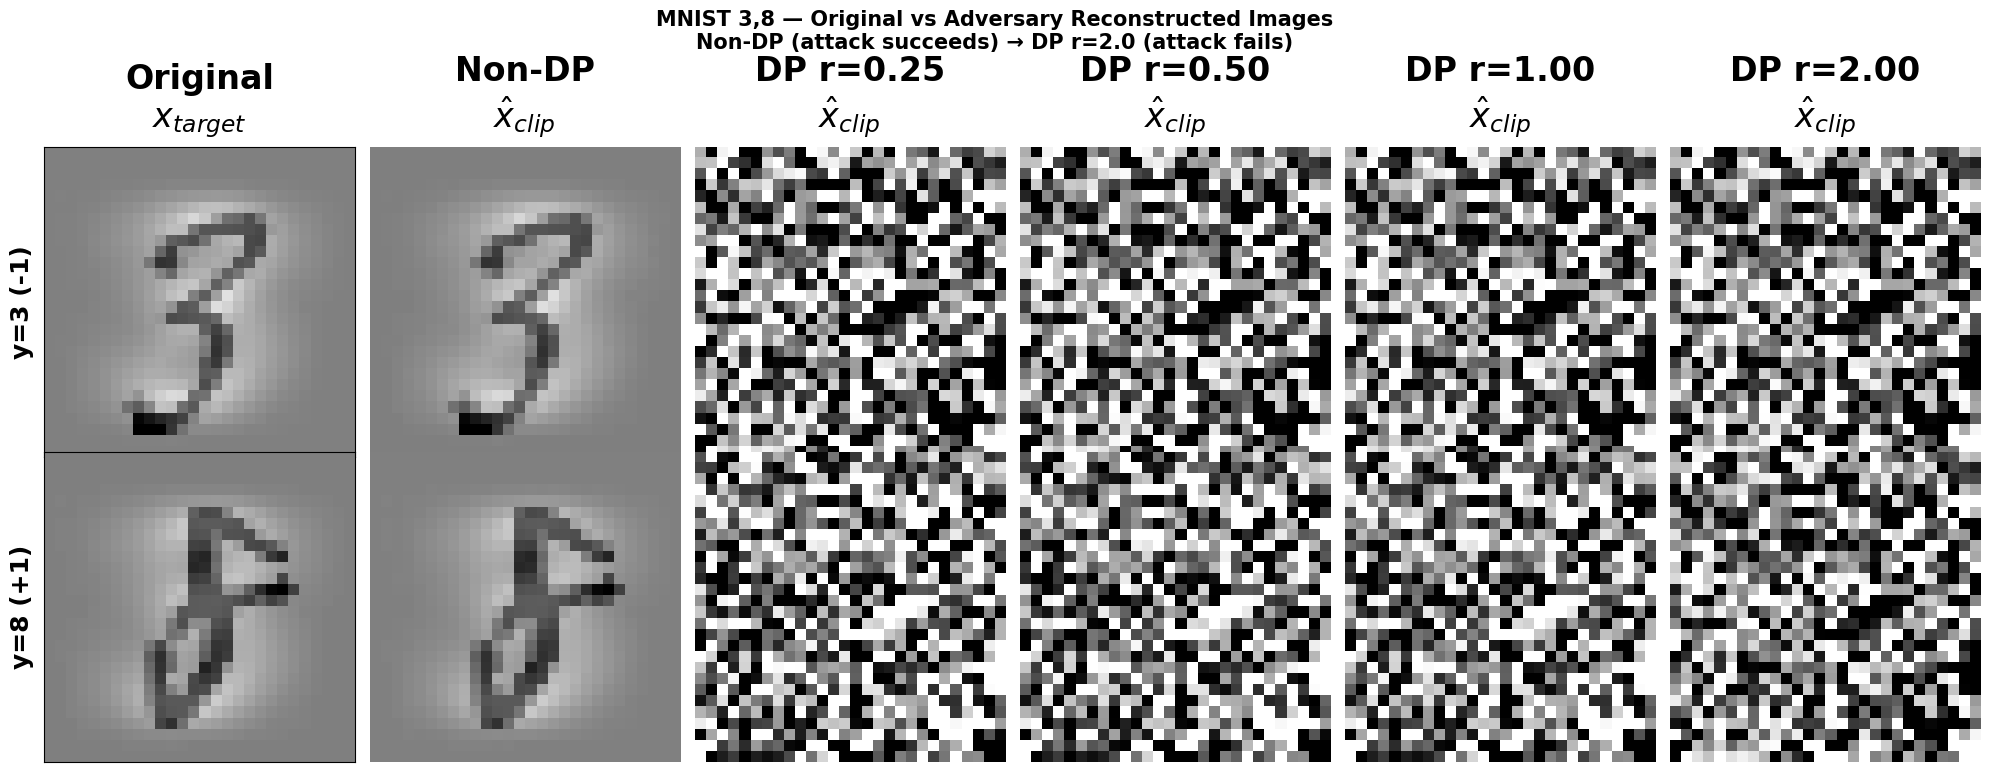

Reconstructed image comparison saved.


In [18]:
# It creates a function that says :-> take normalized dataset, true label, 40 target, clean non-DP, show 5 images
def show_reconstructed_images(X, y, target_indices, theta_nonDP, n_show=2):
    dp_thetas = {} # storing one theta per radius for visualization
    for r in [0.25, 0.50, 1.00, 2.00]:
        theta_dp, _, _ = output_perturbation_gaussian_noise(
            theta_nonDP, r, p_epsilon, p_delta, Lambda_l2, X.shape[0], seed=42)
        dp_thetas[r] = theta_dp # creates one noisy model for each r value
    
    
    vlim = float(np.percentile(np.abs(X), 99))
    imshow_kwargs = dict(cmap='gray_r', vmin=-vlim, vmax=vlim)
    
    idx_3 = next(int(ti) for ti in target_indices if y[int(ti)] == -1)
    idx_8 = next(int(ti) for ti in target_indices if y[int(ti)] == 1)
    selected_targets = [idx_3, idx_8]
    
    
    

# Defines 6 column headers
    col_titles =  [
        'Original\n$x_{target}$', # original true image
        'Non-DP\n$\\hat{x}_{clip}$', # non-DP recovered image
        'DP r=0.25\n$\\hat{x}_{clip}$', # DP r=0.25 recovered
        'DP r=0.50\n$\\hat{x}_{clip}$', # DP r=0.50 recovered
        'DP r=1.00\n$\\hat{x}_{clip}$', # DP r=1.00 recovered
        'DP r=2.00\n$\\hat{x}_{clip}$', # DP r= 2.00 recovered
     ]

    fig, axes = plt.subplots(2, 6, figsize=(20, 8)) # creates grid of subplots
    for col, title in enumerate(col_titles):
        axes[0, col].set_title(title, fontsize=24, fontweight='bold',  pad=14) # setting the column titles

    for row, ti in enumerate(selected_targets):
        

        # Column 0: Original Images for 3,8
        """ Shows true original image:
                   X[ti]-> 784 pixel values for target
                   reshape(28,28) -> convert 784 vector to 28 x 28 images
                   cmap='gray_r' -> dark digit on white background (standard MNIST look)
                   vmin=-vlim,vmax=+vlim -> for crispier digit
                   label_str:
                   y[ti]==1 -> digit 8 -> 8[+1]
                   y[ti]==-1 -> digit 3 -> 3[-1]"""
        
        axes[row, 0].imshow(X[ti].reshape(28, 28), **imshow_kwargs)
        label_str = '8 (+1)' if y[ti] == 1 else '3 (-1)'
        axes[row, 0].set_ylabel(f'y={label_str}', fontsize=18, fontweight='bold')
        axes[row, 0].set_xticks([])
        axes[row, 0].set_yticks([])

        # Column 1: Non-DP reconstruction 
        """ Run reconstruction attack on clean model from which it computes residual, recover x_hat_raw, clip it
        to unit ball, reshape 28 x 28 , display the image
         resulting in image is looking same as original"""     
    
        x_hat_raw, _, success, _ = reconstruct_from_subgradient_residual(
            X, y, ti, theta_nonDP, Lambda_l2)
        if success:
            norm_hat   = float(np.linalg.norm(x_hat_raw))
            scale      = min(1.0, 1.0 / norm_hat) if norm_hat > 1e-10 else 0.0
            x_hat_clip = x_hat_raw * scale
        else:
            x_hat_clip = np.zeros(X.shape[1])
        axes[row, 1].imshow(x_hat_clip.reshape(28, 28), **imshow_kwargs)
        axes[row, 1].axis('off')

        # Columns 2-5: DP reconstructions
        """for each r value:
          col = 2 -> r=0.25 , theta_dp=025
          .......................
          .......................
          col = 5 -> r=2.00 , theta_dp=200
          
          same reconstruction attack as non_DP column 1, but with noisy model, resulting in
          noise corrupts residual, x_hat_raw points wrong direction, clipping pushes to unit ball, images
          looks like noise
        """
        
        for col, (r, theta_dp) in enumerate(dp_thetas.items(), start=2):
            x_hat_raw, _, success, _ = reconstruct_from_subgradient_residual(
                X, y, ti, theta_dp, Lambda_l2)
            if success:
                norm_hat   = float(np.linalg.norm(x_hat_raw))
                scale      = min(1.0, 1.0 / norm_hat) if norm_hat > 1e-10 else 0.0
                x_hat_clip = x_hat_raw * scale
            else:
                x_hat_clip = np.zeros(X.shape[1])
            axes[row, col].imshow(x_hat_clip.reshape(28, 28), **imshow_kwargs)
            axes[row, col].axis('off')

    plt.suptitle(
        'MNIST 3,8 — Original vs Adversary Reconstructed Images\n'
        'Non-DP (attack succeeds) → DP r=2.0 (attack fails)',
        fontsize=15, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig("mnist_reconstructed_images.png", dpi=300, bbox_inches='tight')
    plt.show()
    print("Reconstructed image comparison saved.")

show_reconstructed_images(X, y_label, target_indices, theta_nonDP, n_show=2)

## Plotting for the Graph

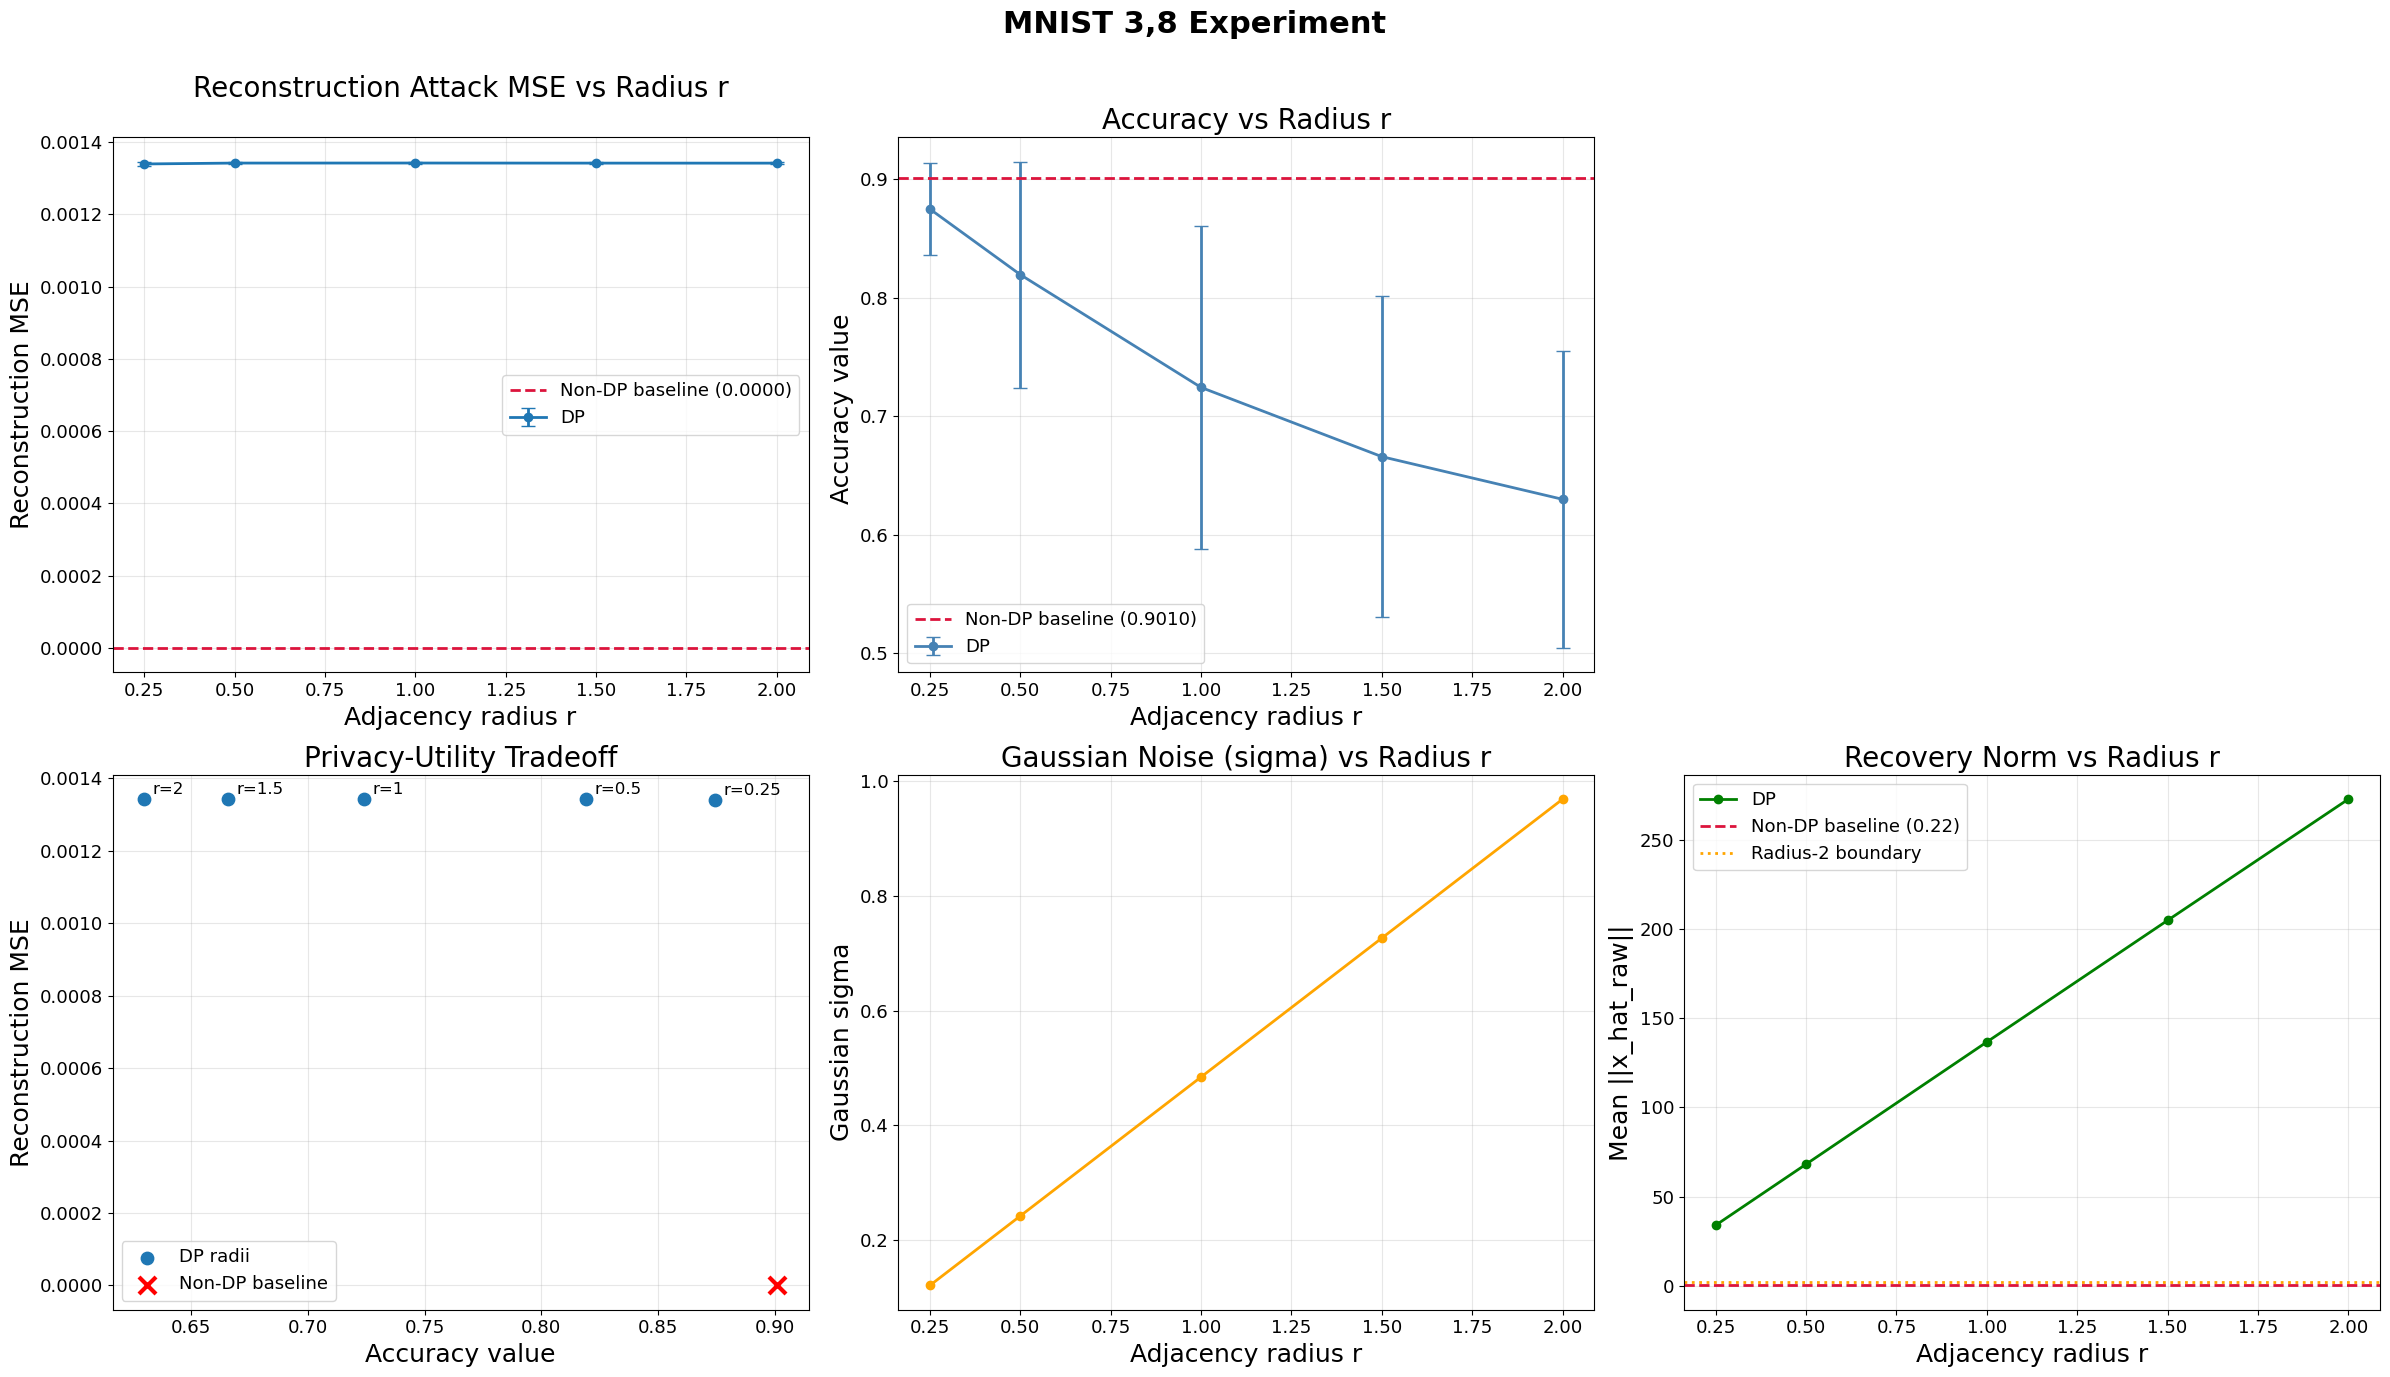

Plots MNIST_3_8_plots.png


In [20]:
r_arr     = results_df["r"].to_numpy()
mse_arr   = results_df["MSE_mean"].to_numpy()
mse_err   = results_df["MSE_std"].to_numpy()
acc_arr   = results_df["Acc_mean"].to_numpy()
acc_err   = results_df["Acc_std"].to_numpy()
sigma_arr = results_df["sigma_mean"].to_numpy()

# Set all font sizes globally for this figure
plt.rcParams.update({
    'axes.titlesize': 20,
    'axes.labelsize': 18,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 13,
})

fig, axes = plt.subplots(2, 3, figsize=(24, 14))
fig.suptitle(
    "MNIST 3,8 Experiment\n",
    fontsize=22, fontweight="bold"
)
axes[0, 2].set_visible(False)

# Plot1: Reconstruction MSE vs r
ax = axes[0, 0]
ax.errorbar(r_arr, mse_arr, yerr=mse_err, marker="o", capsize=5, linewidth=2, label="DP")
ax.axhline(baseline_row["MSE_mean"], linestyle="--", linewidth=2, color="crimson",
           label=f"Non-DP baseline ({baseline_row['MSE_mean']:.4f})")
ax.set_xlabel("Adjacency radius r")
ax.set_ylabel("Reconstruction MSE")
ax.set_title("Reconstruction Attack MSE vs Radius r\n")
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Accuracy vs Radius r
ax = axes[0, 1]
ax.errorbar(r_arr, acc_arr, yerr=acc_err, marker="o", capsize=5, linewidth=2,
            color="steelblue", label="DP")
ax.axhline(baseline_row["Acc_mean"], linestyle="--", linewidth=2, color="crimson",
           label=f"Non-DP baseline ({baseline_row['Acc_mean']:.4f})")
ax.set_xlabel("Adjacency radius r")
ax.set_ylabel("Accuracy value ")
ax.set_title("Accuracy vs Radius r")
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Privacy-utility trade off
ax = axes[1, 0]
ax.scatter(acc_arr, mse_arr, s=80, zorder=3, label="DP radii")
ax.scatter([baseline_row["Acc_mean"]], [baseline_row["MSE_mean"]],
           marker="x", s=150, linewidths=3, color="red", zorder=4, label="Non-DP baseline")
for _, row in results_df.iterrows():
    ax.annotate(
        f"r={row['r']:g}",
        (row["Acc_mean"], row["MSE_mean"]),
        textcoords="offset points", xytext=(6, 4), fontsize=12,
    )
ax.set_xlabel("Accuracy value")
ax.set_ylabel("Reconstruction MSE")
ax.set_title("Privacy-Utility Tradeoff")
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Gaussian sigma vs r
ax = axes[1, 1]
ax.plot(r_arr, sigma_arr, marker="o", linewidth=2, color="orange")
ax.set_xlabel("Adjacency radius r")
ax.set_ylabel("Gaussian sigma")
ax.set_title("Gaussian Noise (sigma) vs Radius r")
ax.grid(True, alpha=0.3)

# Plot 5: ||x_hat_raw|| vs r 
ax = axes[1, 2]
norm_arr = results_df["Mean_xhat_norm"].to_numpy()
ax.plot(r_arr, norm_arr, marker="o", linewidth=2, color="green",
        label="DP")
ax.axhline(baseline_row["Mean_xhat_norm"], linestyle="--",
           linewidth=2, color="crimson",
           label=f"Non-DP baseline ({baseline_row['Mean_xhat_norm']:.2f})")
ax.axhline(2.0, linestyle=":", linewidth=2, color="orange",
           label="Radius-2 boundary")
ax.set_xlabel("Adjacency radius r")
ax.set_ylabel("Mean ||x_hat_raw||")
ax.set_title("Recovery Norm vs Radius r")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("MNIST_3_8_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plots MNIST_3_8_plots.png")